# *E. coli* Fatty Acid Synthesis — Deterministic ODE Model

Simulates the type II FAS pathway using mass-action kinetics. Reaction networks are defined in YAML files and loaded at runtime; the resulting ODE system is solved with JAX + diffrax.

**Workflow:** build network → reaction sanity check → set initial conditions → solve ODEs → make plots

---
*Annette Thompson · Fox and Shirts Labs, CU Boulder · 2026 · Developed with assistance from GitHub Copilot (Claude Sonnet 4.6)*

## Step 1: Load Reaction Network

**What to update before running:**
- **`REACTIONS_PATH`** — set this to the folder containing your YAML reaction files. Update to `Path('../Reactions/EC_FAS_ME1')` once the full YAML folder is in place.

`build_ode_system_from_reactions()` returns:
- `network` — equinox module implementing the ODE right-hand side
- `species` — ordered list of species names
- `params` — ordered list of parameter names
- `param_values` — dict of default rate constants loaded from the YAML files
- `scaling_groups` — named groups of rate constants that can be rescaled together

The `sp`, `pm`, `rn`, and `sg` namespace objects enable **tab-completion**: type `sp.` and press Tab to browse all species, `pm.` for parameters, etc.

In [77]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "../")

from pathlib import Path
import re
import os
import json

import numpy as np
import matplotlib.pyplot as plt
import jax
jax.config.update('jax_enable_x64', True)
import jax.numpy as jnp
import diffrax as dfrx
import pandas as pd
import itertools
from scipy.optimize import minimize

from Utilities.reaction_model_builder import (
    build_ode_system_from_reactions,
    load_elementary_reactions,
    make_namespace,
    make_reaction_namespace,
    set_scaling_group_values
)

REACTIONS_PATH = Path('../Reactions/EC_FAS_ME1/C12/')

network, species, params, param_values, scaling_groups = build_ode_system_from_reactions(REACTIONS_PATH)
rxns = load_elementary_reactions(REACTIONS_PATH)

# Namespaces enable tab-completion: sp.ACP, pm.k3_1f, rn.FabG_binding_NADPH
sp = make_namespace(species)
pm = make_namespace(params)
rn = make_reaction_namespace(rxns)
sg = make_namespace(scaling_groups)

theta = jnp.array([param_values[p] for p in params], dtype=jnp.float64)

print(f'Loaded {len(species)} species, {len(params)} params, {len(rxns)} reactions, and {len(scaling_groups)} scaling groups.')

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Loaded 139 species, 151 params, 132 reactions, and 17 scaling groups.


## Step 2: Sanity Checks

Checks reaction definitions for common errors before committing to a long simulation:
- Mass balance (atoms conserved across each reaction)
- Species continuity (every produced species is also consumed somewhere)
- Chain-set consistency (for fatty acid chain-length templates)
- Suspiciously similar rate-constant names (typo detection)
- Zero-valued rate constants

In [2]:
import importlib, Utilities.reaction_sanity_check
importlib.reload(Utilities.reaction_sanity_check)
from Utilities.reaction_sanity_check import run_all_checks

sanity = run_all_checks(rxns)

Running sanity checks on 145 expanded reactions

══════════════════════════════════════════════════════════════
MASS BALANCE
  Moieties: Carbon, CoA, ACP, NAD, NADP
  145/145 reactions balanced
  All reactions balanced ✓

══════════════════════════════════════════════════════════════
SPECIES CONTINUITY CHECK
  Total species:                      160
  Never created as a forward product: 5
  Never consumed as a reactant:       37
  Appear in exactly one reaction:     36

  [INFO] Never created in forward reactions (starting substrates check):


species,used_in
C2_AcACP,"FabB_binding_C2_AcACP, FabF_binding_C2_AcACP"
C2_AcCoA,"C2_FabB_binding_AcCoA, C2_FabH_binding_AcCoA"
C3_MalCoA,FabD_binding_MalCoA
NADH,FabI_binding_NADH
NADPH,FabG_binding_NADPH



  [INFO] Never consumed in forward reactions (terminal products or sinks check):


species,produced_in
C10_FA,C10_TesA_hydrolysis_release_FA
C10_FabH_AcACP,C10_FabH_inhibition_by_AcACP
C10_FabH_Act_AcACP,C8_C2_FabH_Act_inhibition_by_AcACP
C12_FA,C12_TesA_hydrolysis_release_FA
C12_FabH_AcACP,C12_FabH_inhibition_by_AcACP
C12_FabH_Act_AcACP,C10_C2_FabH_Act_inhibition_by_AcACP
C14_FA,C14_TesA_hydrolysis_release_FA
C14_FabH_AcACP,C14_FabH_inhibition_by_AcACP
C14_FabH_Act_AcACP,C12_C2_FabH_Act_inhibition_by_AcACP
C16_FA,C16_TesA_hydrolysis_release_FA



  [WARN] Species appearing in exactly one reaction (possible dead-end or mistype):


...


  Parameter keys:


name_a,name_b,score,note
C14_C2_koff_H_Act_AcACP,C4_C2_koff_H_Act_AcACP,0.98,high similarity (0.98)
C16_C2_koff_H_Act_AcACP,C6_C2_koff_H_Act_AcACP,0.98,high similarity (0.98)
C18_C2_koff_H_Act_AcACP,C8_C2_koff_H_Act_AcACP,0.98,high similarity (0.98)
C16_kcat_B_BKeAcACP,C6_kcat_B_BKeAcACP,0.97,high similarity (0.97)
C14_kon_Z_BHyAcACP,C4_kon_Z_BHyAcACP,0.97,high similarity (0.97)
C16_kon_Z_BHyAcACP,C6_kon_Z_BHyAcACP,0.97,high similarity (0.97)
C18_kon_Z_BHyAcACP,C8_kon_Z_BHyAcACP,0.97,high similarity (0.97)
C14_kon_Z_EnAcACP,C4_kon_Z_EnAcACP,0.97,high similarity (0.97)
C16_kon_Z_EnAcACP,C6_kon_Z_EnAcACP,0.97,high similarity (0.97)
C18_kon_Z_EnAcACP,C8_kon_Z_EnAcACP,0.97,high similarity (0.97)



══════════════════════════════════════════════════════════════
ZERO-RATE REACTIONS
  No zero-rate reactions ✓

══════════════════════════════════════════════════════════════
IRREVERSIBLE ACCUMULATION AND DRAIN CHECK
  Irreversibly generated, never consumed: 11
  Irreversibly consumed, never generated: 0

  [ACCUMULATE] Generated by irreversible reaction(s) but never consumed:


species,source_reactions
C10_FA,C10_TesA_hydrolysis_release_FA
C12_FA,C12_TesA_hydrolysis_release_FA
C14_FA,C14_TesA_hydrolysis_release_FA
C16_FA,C16_TesA_hydrolysis_release_FA
C18_FA,C18_TesA_hydrolysis_release_FA
C1_CO2,"C6_FabB_condensation_release_BKeAcACP, C8_FabB_condensation_release_BKeAcACP, C10_FabB_condensation_release_BKeAcACP, C12_FabB_condensation_release_BKeAcACP, C14_FabB_condensation_release_BKeAcACP, C16_FabB_condensation_release_BKeAcACP, FabB_decarboxylating_MalACP, C18_FabF_condensation_release_BKeAcACP, FabF_decarboxylating_MalACP, C5_FabH_Act_condensation_release_BKeAcACP"
C4_FA,C4_TesA_hydrolysis_release_FA
C6_FA,C6_TesA_hydrolysis_release_FA
C8_FA,C8_TesA_hydrolysis_release_FA
NAD,"C4_FabI_catalysis_release_AcACP, C6_FabI_catalysis_release_AcACP, C8_FabI_catalysis_release_AcACP, C10_FabI_catalysis_release_AcACP, C12_FabI_catalysis_release_AcACP, C14_FabI_catalysis_release_AcACP, C16_FabI_catalysis_release_AcACP, C18_FabI_catalysis_release_AcACP"



══════════════════════════════════════════════════════════════
PARAMETER CONFLICT CHECK
  No parameter conflicts ✓


## Tools for Inspecting Reactions

Use these helpers to debug reaction definitions and quickly inspect model structure.

`rxns.query(query, query_type, *, return_type="expression")` searches reactions by field.

- `query_type` (required): `"species"`, `"reactant"`, `"product"`, `"parameter"`, `"scaling"`, or any reaction attribute (for example `"rxn_name"`)
- `query`: substring text (contains match) or a namespace index like `sp.X`, `pm.k`, `sg.a1` (exact match); can use Regular Expression to search for patterns (requires use_regex = True)
- `return_type` (optional): `"expression"` (default), `"parameters"` (includes parameter values), `"scaling"`, `"ode_terms"`, or `"scaled_rate_constants"` (effective rate = base × scaling factor; requires `theta=theta`)

`rxns.get_ode_terms(sp.X)` is a shortcut for the species mass-balance view.

In [3]:
rxns.query("FabD", "species", return_type="expression",use_regex=True, theta=theta)

4 match(es) | species='FabD' | return=expression


rxn_name,reaction,rate_expression
FabD_binding_MalCoA,FabD + C3_MalCoA <--> C3_FabD_MalCoA,kon_D_MalCoA * FabD * C3_MalCoA <--> a1 * koff_D_MalCoA * C3_FabD_MalCoA
FabD_activation_release_CoA,C3_FabD_MalCoA <--> C3_FabD_Act + CoA,(b1/b2) * kfwd_D_MalCoA * C3_FabD_MalCoA <--> b1 * krvs_D_MalCoA * C3_FabD_Act * CoA
FabD_Act_binding_ACP,C3_FabD_Act + ACP <--> C3_FabD_Act_ACP,kon_D_Act_ACP * C3_FabD_Act * ACP <--> a1 * koff_D_Act_ACP * C3_FabD_Act_ACP
FabD_catalysis_release_MalACP,C3_FabD_Act_ACP <--> FabD + C3_MalACP,(b1/b3) * kfwd_D_Act_ACP * C3_FabD_Act_ACP <--> b1 * krvs_D_Act_ACP * FabD * C3_MalACP


## Step 3: Simulation Parameters

**What to change here:**
- **`y0[sp.X] = value`** — starting concentration (µM) of each species (substrates).
- **`enzyme_concs`** — enzyme starting concentrations (µM).
- **`SCALING_GROUPS`** — scalar multipliers applied uniformly to all rate constants in a named group (groups set in reaction files).

In [78]:
y0 = np.zeros(len(species), dtype=np.float64)

# Substrates (µM) - set non-zero starting concentrations 
y0[sp.C2_AcCoA]  = 500.0
y0[sp.C3_MalCoA] = 500.0
y0[sp.ACP]       = 10.0
y0[sp.NADPH]     = 1000.0
y0[sp.NADH]      = 1000.0

# Enzymes (µM)
enzyme_concs = {
    sp.FabD: 1, sp.FabH: 1, sp.FabG: 1, sp.FabZ: 1,
    sp.FabI: 1, sp.TesA: 10, sp.FabF: 1, sp.FabB: 1, sp.FabA: 1,
}
for idx, conc in enzyme_concs.items():
    y0[idx] = float(conc)

# Scaling group values - setting to 1 or 0 will leave parameters alone 
# depending on the scaling parameter (some are within expressions used to scale)
SCALING_GROUPS = {
    "a1": 1, "a2": 1, "a3": 1,
    "b1": 1, "b2": 1, "b3": 1,
    "c1": 1, "c2": 1, "c3": 1, "c4": 1,
    "d1": 0, "d2": 0, "e": 1, # "f": 1,
    "x1": 1, "x2": 1, "x3": 1, "x4": 1,
}
theta = set_scaling_group_values(theta, params, SCALING_GROUPS)

## Step 4: Solve ODEs

**What to change here:**
- **`time_range = [0.0, 720.0]`** — simulation start and end time in **seconds** (720 s = 12 min (product profile), 150 s = 2.5 min (initial rate)). Increase the upper bound to let the system approach steady state.

The solver used is **Kvaerno5** — an implicit, stiff-safe 5th-order Runge–Kutta method with adaptive step size via a PID controller. Every accepted step is saved; trailing NaN padding is trimmed after solving. Time units are **seconds** internally.

In [56]:
def run_odes(time_range, y0, theta_run, max_steps=1_500, save_steps=True):
    
    sol = dfrx.diffeqsolve(
        dfrx.ODETerm(network),
        dfrx.Kvaerno5(),
        t0=time_range[0], t1=time_range[1], dt0=1e-6,
        y0=jnp.asarray(y0, dtype=jnp.float64),
        args=theta_run,
        saveat=dfrx.SaveAt(steps=True) if save_steps else dfrx.SaveAt(t1=True),
        stepsize_controller=dfrx.PIDController(
            rtol=1e-4, atol=1e-8, pcoeff=0.2, icoeff=0.4, dcoeff=0,
        ),
        max_steps=max_steps,
        throw=False,
    )

    num_tot_steps = int(np.asarray(sol.stats['num_steps']))

    if num_tot_steps >= max_steps or bool(sol.result != dfrx.RESULTS.successful):
        print(f"Solver did not converge within {max_steps} steps -- bad conditions, skipping.")
        return None, None

    num_ac_steps = int(np.asarray(sol.stats['num_accepted_steps']))

    if save_steps:
        T = sol.ts[:num_ac_steps]
        C = sol.ys[:num_ac_steps, :]
    else:
        T = sol.ts
        C = sol.ys if sol.ys.ndim == 2 else sol.ys[None, :]

    print(f"{num_ac_steps} accepted steps, {num_tot_steps} total steps.")

    return T, C

In [80]:
time_range = [0.0, 720.0]  # seconds
T, C = run_odes(time_range, y0, theta)

116 accepted steps, 116 total steps.


## Step 5: Plotting

### Fatty Acid Chain-Length Profile

Stacked bar chart of final (end-of-simulation) fatty acid mole fractions, split by saturated vs. unsaturated. Species matching `C<n>_FA` and `C<n>_FA_un` are collected and totaled across all chain lengths.

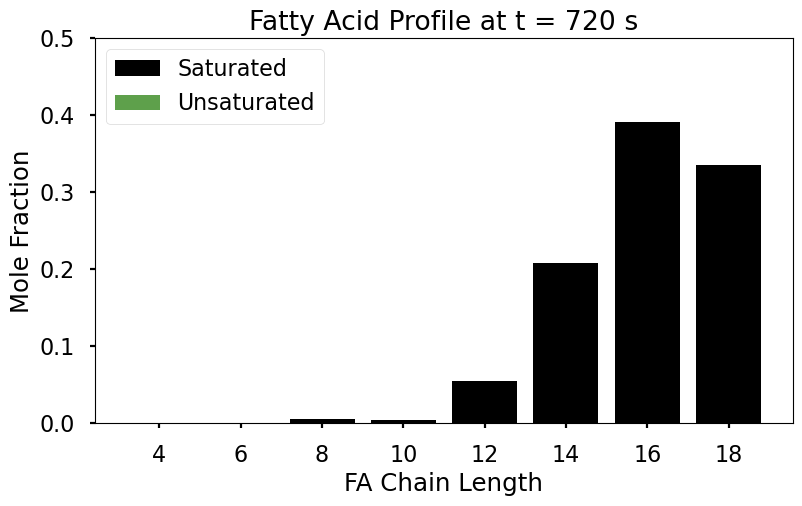

In [27]:
# Collect final concentrations of all C<n>_FA (sat) and C<n>_FA_un (unsat) species
SP_PATTERN = re.compile(r'^C(\d+)_FA(_unsat)?$')
sat_by_chain: dict[int, float] = {}
unsat_by_chain: dict[int, float] = {}
final_conc = C[-1, :]

for sp_name in species:
    m = SP_PATTERN.match(sp_name)
    if m is None:
        continue
    chain = int(m.group(1))
    val = float(final_conc[getattr(sp, sp_name)])
    (unsat_by_chain if m.group(2) else sat_by_chain)[chain] = \
        (unsat_by_chain if m.group(2) else sat_by_chain).get(chain, 0.0) + val

chains = sorted(set(sat_by_chain) | set(unsat_by_chain))
sat   = np.array([sat_by_chain.get(c, 0.0)   for c in chains])
unsat = np.array([unsat_by_chain.get(c, 0.0) for c in chains])
tot = sat.sum() + unsat.sum()

# Normalize to mole fractions (avoid divide-by-zero if all zero)
sat_frac   = np.divide(sat,   tot, out=np.zeros_like(sat),   where=tot > 0)
unsat_frac = np.divide(unsat, tot, out=np.zeros_like(unsat), where=tot > 0)

plt.style.use('seaborn-v0_8-poster')
plt.rcParams['axes.prop_cycle'] = plt.cycler(
    color=[plt.cm.gist_earth(i / 2) for i in range(2)]
)

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(chains))
ax.bar(x, sat_frac,   label='Saturated')
ax.bar(x, unsat_frac, bottom=sat_frac, label='Unsaturated')
ax.set_xticks(x)
ax.set_xticklabels([str(c) for c in chains])
ax.set_xlabel('FA Chain Length')
ax.set_ylabel('Mole Fraction')
ax.set_title('Fatty Acid Profile at t = {:.0f} s'.format(float(T[-1])))
ax.legend()
ax.set_ylim(0, 0.5)
plt.show()

### Concentration Trajectories

`plot_species(names)` accepts any mix of `sp.<name>` integer indices or plain string names. Pass `log_y=True` for species that span several orders of magnitude.

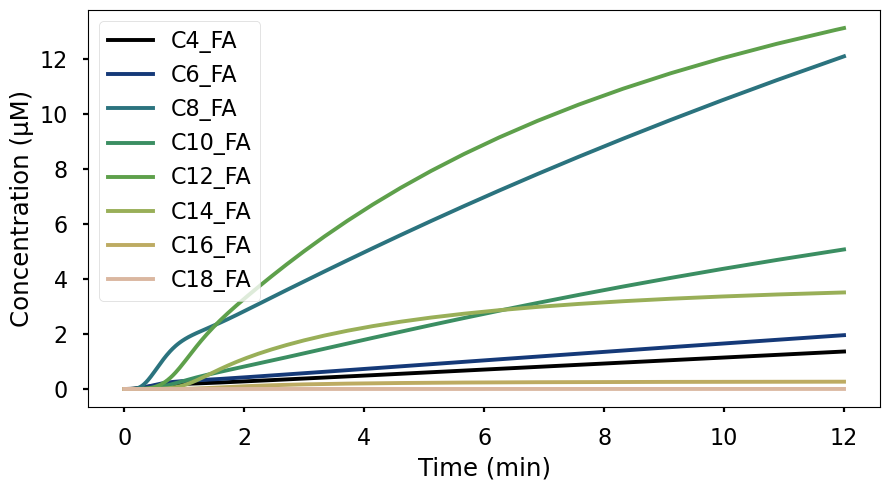

In [18]:
def plot_species(names: list, *, log_y: bool = False) -> None:
    """Plot concentration vs time. Accepts sp.<name> indices or string names."""
    fig, ax = plt.subplots(figsize=(9, 5))
    for name in names:
        idx, label = (name, species[name]) if isinstance(name, int) else (getattr(sp, name), name)
        ax.plot(T / 60, C[:, idx], label=label)
    ax.set_xlabel('Time (min)')
    ax.set_ylabel('Concentration (µM)')
    if log_y:
        ax.set_yscale('log')
    ax.legend()
    fig.tight_layout()
    plt.show()


species_list = [sp.C4_FA, sp.C6_FA, sp.C8_FA, sp.C10_FA, sp.C12_FA, sp.C14_FA, sp.C16_FA, sp.C18_FA]
plt.style.use('seaborn-v0_8-poster')
plt.rcParams['axes.prop_cycle'] = plt.cycler(
    color=[plt.cm.gist_earth(i / len(species_list)) for i in range(len(species_list))]
)

plot_species(species_list)